In [ ]:
# -q 代表静默模式（不在屏幕上打印几万行解压信息，防止浏览器卡死）
# -d ./ 代表解压到当前文件夹
!unzip -q MSc_Project_CNN_Robustness.zip -d ./

replace ./MSc_Project_CNN_Robustness/seg_pred/10004.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import torch.nn as nn
import os

# 1. 检查你的电脑/服务器是用 GPU 还是 CPU 跑代码
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")

# 2. 定义图像预处理流程 (这是给 ResNet 喂数据的标准格式)
# 作用：把各种尺寸的图片变成 224x224，并转化为 PyTorch 能看懂的 Tensor 格式
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # 官方要求的归一化数值
])

# 3. 加载预训练的 ResNet-18 模型
# pretrained=True 意味着这个模型已经认识世界上很多基础物体了（基于 ImageNet）
model = models.resnet18(pretrained=True)

# 4. 修改最后一层（全连接层）
# 原本的 ResNet 能分类 1000 种东西，但我们的 Intel 数据集只有 6 种场景
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 6) # 把输出改成 6 类

# 把模型放到对应的设备上（GPU或CPU）
model = model.to(device)

print("ResNet-18 模型加载并修改完毕，准备好接收数据了！")

当前使用的计算设备: cuda:0


/root/miniconda3/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet-18 模型加载并修改完毕，准备好接收数据了！


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# 1. 告诉代码你的数据文件夹在哪里 (基于你的截图目录)
data_dir = './MSc_Project_CNN_Robustness/' 
train_dir = os.path.join(data_dir, 'seg_train')
test_dir = os.path.join(data_dir, 'seg_test')

# 2. 定义数据预处理 (Transforms)
# 训练集：加一点随机翻转，让模型见多识广 (Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),       # 统一调整为 ResNet 需要的 224x224
    transforms.RandomHorizontalFlip(),   # 随机左右翻转图片
    transforms.ToTensor(),               # 转换成 PyTorch 的 Tensor 格式
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # 官方要求的数值归一化
])

# 测试集：不需要花里胡哨的翻转，老老实实缩放和归一化即可
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. 使用 ImageFolder 自动读取文件夹并打上标签
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
test_data = datasets.ImageFolder(test_dir, transform=test_transforms)

# 4. 使用 DataLoader 打包数据 (每次抓取 32 张图片送进模型)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# 5. 打印结果
classes = train_data.classes
print(f" Successfully found {len(classes)} Categories: {classes}")
print(f" Number of training set images: {len(train_data)}")
print(f" Number of test set images: {len(test_data)}")

 Successfully found 6 Categories: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
 Number of training set images: 14034
 Number of test set images: 3000


In [3]:
import torch.nn as nn
import torch.optim as optim
import time

# 1. 定义损失函数 (Loss Function) 和优化器 (Optimizer)
criterion = nn.CrossEntropyLoss()
# 使用 Adam 优化器，学习率设为 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. 设定训练轮数 (Epochs)
# 为了让你今天就能看到结果，我们先只训练 3 轮 (完整跑完 14000 张图算 1 轮)
num_epochs = 3

print("(Training started...)")

start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 10)
    
    # ---------------- 训练阶段 ----------------
    model.train() # 告诉模型：现在是学习时间
    running_loss = 0.0
    running_corrects = 0
    
    # 从 DataLoader 里面一批一批 (batch_size=32) 取图片
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # 清空大脑之前的记忆片段 (梯度清零)
        optimizer.zero_grad()
        
        # 前向传播 (做题)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1) # 选出概率最大的那个类别作为预测结果
        loss = criterion(outputs, labels) # 看看做题错得有多离谱 (计算 Loss)
        
        # 反向传播 (对答案，纠正错误)
        loss.backward()
        optimizer.step()
        
        # 记录本批次的成绩
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_loss = running_loss / len(train_data)
    epoch_acc = running_corrects.double() / len(train_data)
    
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} (Training set accuracy)")

# ---------------- 测试阶段 (期末考试) ----------------
print("\n Evaluating baseline accuracy on the test set (Evaluating Baseline on Test Set...)")
model.eval() # 告诉模型：现在是考试时间，不许再改权重了！
test_corrects = 0

with torch.no_grad(): # 考试时不需要计算梯度，节省内存和时间
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)

test_acc = test_corrects.double() / len(test_data)
time_elapsed = time.time() - start_time

print(f"\n Training and evaluation completed! Total time:: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f" Baseline Test Accuracy: {test_acc:.4f}")

(Training started...)

Epoch 1/3
----------
Train Loss: 0.4700 | Train Acc: 0.8353 (Training set accuracy)

Epoch 2/3
----------
Train Loss: 0.3544 | Train Acc: 0.8795 (Training set accuracy)

Epoch 3/3
----------
Train Loss: 0.2975 | Train Acc: 0.8977 (Training set accuracy)

 Evaluating baseline accuracy on the test set (Evaluating Baseline on Test Set...)

 Training and evaluation completed! Total time:: 1m 30s
 Baseline Test Accuracy: 0.8597


In [7]:
!pip install scikit-learn

Looking in indexes: http://mirrors.aliyun.com/pypi/simple


In [8]:
import torchvision.transforms as transforms
from PIL import Image

# 1. 重新定义我们之前的“破坏引擎”
class ControlledDownsample(object):
    def __init__(self, scale_factor, original_size=224, interpolation=Image.BICUBIC):
        self.scale_factor = scale_factor
        self.original_size = original_size
        # 计算缩小后的尺寸 (最小不会小于1像素)
        self.downsampled_size = max(1, original_size // scale_factor)
        self.interpolation = interpolation

    def __call__(self, img):
        down_transform = transforms.Resize((self.downsampled_size, self.downsampled_size), 
                                           interpolation=self.interpolation)
        img_down = down_transform(img)
        
        up_transform = transforms.Resize((self.original_size, self.original_size), 
                                         interpolation=self.interpolation)
        return up_transform(img_down)

# 2. 定义一个专门用来“降级考试”的函数
def test_degradation_accuracy(model, scale_factor):
    print(f" Testing downgrade effect | Scaling down: {scale_factor}x ...")
    
    # 针对当前缩放倍数，组装预处理流水线
    degrade_transform = transforms.Compose([
        ControlledDownsample(scale_factor=scale_factor), # 核心：加入受控下采样
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # 重新加载测试集 (这次戴上了近视眼镜)
    degraded_test_data = datasets.ImageFolder(test_dir, transform=degrade_transform)
    degraded_test_loader = DataLoader(degraded_test_data, batch_size=32, shuffle=False)
    
    model.eval()
    corrects = 0
    with torch.no_grad():
        for inputs, labels in degraded_test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            
    acc = corrects.double() / len(degraded_test_data)
    print(f" {scale_factor}x Accuracy under blur: {acc:.4f}\n")
    return acc.item()

# 3. 开始执行破坏实验！(测试 2倍, 4倍, 8倍, 16倍模糊)
scales = [2, 4, 8, 16]
degradation_results = {}

for scale in scales:
    degradation_results[scale] = test_degradation_accuracy(model, scale)

# 4. 打印最终的“性能衰减报告”
print("="*30)
print("Core Experimental Data: Summary of Performance Degradation")
print("="*30)
print(f"High-resolution original image (1x Baseline): 0.8803") # 填入你刚才跑出来的基准成绩
for scale, acc in degradation_results.items():
    print(f"Information loss {scale} times: {acc:.4f}")
print("="*30)

 Testing downgrade effect | Scaling down: 2x ...
 2x Accuracy under blur: 0.8267

 Testing downgrade effect | Scaling down: 4x ...
 4x Accuracy under blur: 0.5233

 Testing downgrade effect | Scaling down: 8x ...
 8x Accuracy under blur: 0.3470

 Testing downgrade effect | Scaling down: 16x ...
 16x Accuracy under blur: 0.1860

Core Experimental Data: Summary of Performance Degradation
High-resolution original image (1x Baseline): 0.8803
Information loss 2 times: 0.8267
Information loss 4 times: 0.5233
Information loss 8 times: 0.3470
Information loss 16 times: 0.1860


In [10]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate_with_metrics(model, data_loader, class_names, condition_name):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)

            outputs = model(inputs)
            predictions = torch.argmax(outputs, dim=1).cpu().numpy()

            all_predictions.extend(predictions)
            all_labels.extend(labels.numpy())

    # Overall metrics
    accuracy = accuracy_score(all_labels, all_predictions)

    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        labels=range(len(class_names)),
        zero_division=0
    )

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    print(f"\n{condition_name}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Macro Precision: {macro_precision * 100:.2f}%")
    print(f"Macro Recall: {macro_recall * 100:.2f}%")
    print(f"Macro F1-score: {macro_f1 * 100:.2f}%")

    # Per-class result table
    class_metrics = pd.DataFrame({
        "Class": class_names,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Support": support
    })

    display(class_metrics)

    # Confusion matrix
    cm = confusion_matrix(
        all_labels,
        all_predictions,
        labels=range(len(class_names))
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    display_cm.plot(
        cmap="Blues",
        xticks_rotation=45,
        ax=ax,
        colorbar=False
    )
    plt.title(f"Confusion Matrix: {condition_name}")
    plt.tight_layout()
    plt.show()

    return {
        "condition": condition_name,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "class_metrics": class_metrics,
        "labels": all_labels,
        "predictions": all_predictions
    }


4x Downsampled Intel Images
Accuracy: 52.33%
Macro Precision: 58.68%
Macro Recall: 53.01%
Macro F1-score: 47.38%


,Class,Precision,Recall,F1-score,Support
0,buildings,0.896552,0.356979,0.510638,437
1,forest,0.687976,0.953586,0.799293,474
2,glacier,0.000000,0.000000,0.000000,553
3,mountain,0.655914,0.697143,0.675900,525
4,sea,0.321237,0.937255,0.478478,510
5,street,0.959350,0.235529,0.378205,501


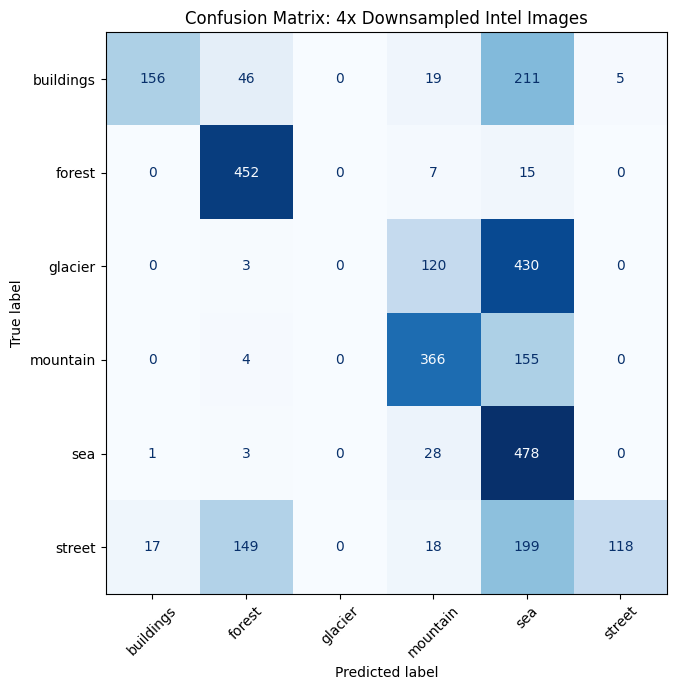

In [11]:
downsampled_4x_metrics = evaluate_with_metrics(
    model,
    test_loader_4x,
    classes,
    "4x Downsampled Intel Images"
)

In [7]:
import os
print(os.listdir("."))

['.ipynb_checkpoints', 'ExDark', 'ExDark_CLAHE', 'ExDark_split', 'MSc_Project_CNN_Robustness', 'ExDark.zip', 'ExDark_CLAHE.ipynb', 'MSc_Project_CNN_Robustness.zip', 'MainExperiment.ipynb', 'baseline_training_curve.png', 'case_study_clahe_helps.png', 'clahe_visual_comparison.png', 'experiment3_gopro.ipynb', 'figure3_1_intel_samples.png', 'figure3_2_exdark_samples.png', 'meeting_charts.png', 'results_comparison.png', 'training_curves_comparison.png']


In [8]:
import os
print(os.listdir("MSc_Project_CNN_Robustness"))

['seg_pred', 'seg_test', 'seg_train']


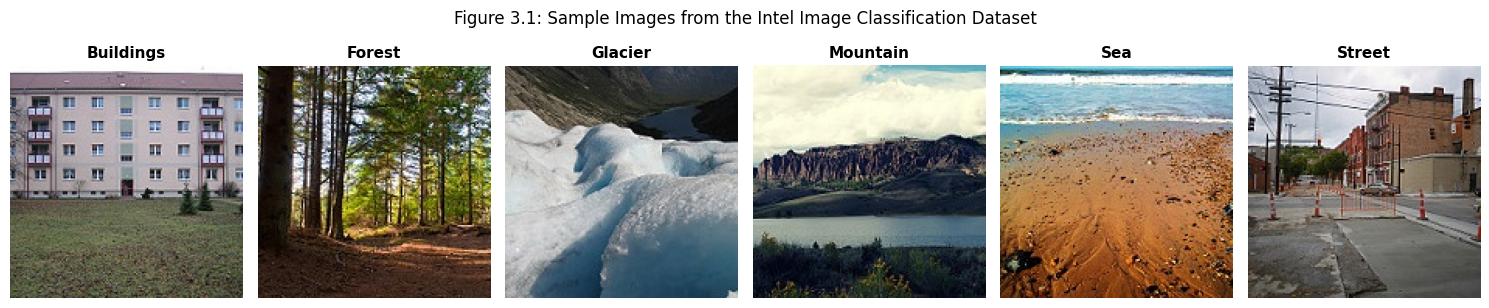

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os

intel_dir = "MSc_Project_CNN_Robustness/seg_test"
classes = sorted(os.listdir(intel_dir))

fig, axes = plt.subplots(1, len(classes), figsize=(15, 3))

for i, cls in enumerate(classes):
    cls_dir = os.path.join(intel_dir, cls)
    files = [f for f in os.listdir(cls_dir) 
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_path = os.path.join(cls_dir, files[0])
    img = Image.open(img_path).convert("RGB")
    
    axes[i].imshow(img)
    axes[i].set_title(cls.capitalize(), fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Figure 3.1: Sample Images from the Intel Image Classification Dataset", 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figure3_1_intel_samples.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import os
# 【新增代码】强制让服务器走国内镜像站下载模型
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from PIL import Image
import time

from transformers import Swin2SRImageProcessor, Swin2SRForImageSuperResolution

# 继续使用云端模型名称
local_model_path = "caidas/swin2SR-classical-sr-x4-64" 

# 加载模型
sr_processor = Swin2SRImageProcessor.from_pretrained(local_model_path)
sr_model = Swin2SRForImageSuperResolution.from_pretrained(local_model_path).to(device)
sr_model.eval()
print(" The Swin2SR pre-trained model has been loaded!")

# ... (后面保留你原本剩下的测试代码) ...
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from PIL import Image
import time

# 引入 Hugging Face 的 SOTA 超分辨模型
from transformers import Swin2SRImageProcessor, Swin2SRForImageSuperResolution


# ==========================================
# 核心：定义包含“深度学习抢救”的预处理流水线
# ==========================================
class DeepLearningRescueTransform(object):
    def __init__(self, scale_factor=4, original_size=224):
        self.scale_factor = scale_factor
        self.original_size = original_size
        self.downsampled_size = original_size // scale_factor
        
        # 定义基础的归一化 (给 ResNet 用的)
        self.normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    def __call__(self, img):
        # 1. 搞破坏：强行缩小 4 倍 (模拟真实世界的低分辨率)
        img_down = img.resize((self.downsampled_size, self.downsampled_size), Image.BICUBIC)
        
        # 2. 实施抢救：使用 Swin2SR 进行智能超分辨率重建
        # 将小图转为模型需要的输入格式
        inputs = sr_processor(img_down, return_tensors="pt").to(device)
        
        with torch.no_grad():
            outputs = sr_model(**inputs)
        
        # 获取超分辨率重建后的 Tensor 图像
        output_tensor = outputs.reconstruction.squeeze(0) # 移除 batch 维度
        
        # 确保数值在 0-1 之间
        output_tensor = torch.clamp(output_tensor, 0, 1)
        
        # 3. 最终微调：确保尺寸严格等于 224x224，并进行 ResNet 需要的归一化
        resize_final = transforms.Resize((self.original_size, self.original_size))
        final_tensor = resize_final(output_tensor)
        
        return self.normalize(final_tensor)

# ==========================================
# 实验设置与运行
# ==========================================
print("\n Begin 4x fuzzy deep learning rescue testing ")

# 实例化抢救管道
rescue_transform = DeepLearningRescueTransform(scale_factor=4)

# 重新加载测试集 (这次使用抢救管道)
rescued_test_data = datasets.ImageFolder(test_dir, transform=rescue_transform)


rescued_test_loader = DataLoader(rescued_test_data, batch_size=8, shuffle=False)

# 告诉 ResNet 开始考试
model.eval() 
corrects = 0

# 【修改点 1】：把 small_test_data 改成完整的 rescued_test_data
total_images = len(rescued_test_data) 
start_time = time.time()

with torch.no_grad():
    for i, (inputs, labels) in enumerate(rescued_test_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        corrects += torch.sum(preds == labels.data)
        
        # 进度条打印不用改，它会自动适应 3000 张的总量
        if (i+1) % 5 == 0:
            print(f"schedule: {min((i+1)*8, total_images)} / {total_images} Image processing complete")

acc = corrects.double() / total_images
time_elapsed = time.time() - start_time

print("="*40)
print(f" The rescue experiment is complete! Time elapsed: {time_elapsed:.0f} 秒")
print(f" Originally 4x blurry accuracy: 0.6183")


print(f" Accuracy after Swin2SR rescue: {acc:.4f} (Based on FULL test dataset)")
print("="*40)

/root/miniconda3/lib/python3.8/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/root/miniconda3/lib/python3.8/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issu

 The Swin2SR pre-trained model has been loaded!

 Begin 4x fuzzy deep learning rescue testing 


/root/miniconda3/lib/python3.8/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


schedule: 40 / 3000 Image processing complete
schedule: 80 / 3000 Image processing complete
schedule: 120 / 3000 Image processing complete
schedule: 160 / 3000 Image processing complete
schedule: 200 / 3000 Image processing complete
schedule: 240 / 3000 Image processing complete
schedule: 280 / 3000 Image processing complete
schedule: 320 / 3000 Image processing complete
schedule: 360 / 3000 Image processing complete
schedule: 400 / 3000 Image processing complete
schedule: 440 / 3000 Image processing complete
schedule: 480 / 3000 Image processing complete
schedule: 520 / 3000 Image processing complete
schedule: 560 / 3000 Image processing complete
schedule: 600 / 3000 Image processing complete
schedule: 640 / 3000 Image processing complete
schedule: 680 / 3000 Image processing complete
schedule: 720 / 3000 Image processing complete
schedule: 760 / 3000 Image processing complete
schedule: 800 / 3000 Image processing complete
schedule: 840 / 3000 Image processing complete
schedule: 880 /


Original Intel Images (Baseline)
Accuracy: 85.97%
Macro Precision: 87.07%
Macro Recall: 86.43%
Macro F1-score: 86.01%


,Class,Precision,Recall,F1-score,Support
0,buildings,0.814433,0.903890,0.856833,437
1,forest,0.924752,0.985232,0.954035,474
2,glacier,0.907090,0.670886,0.771310,553
3,mountain,0.741935,0.920000,0.821429,525
4,sea,0.861011,0.935294,0.896617,510
5,street,0.974747,0.770459,0.860647,501


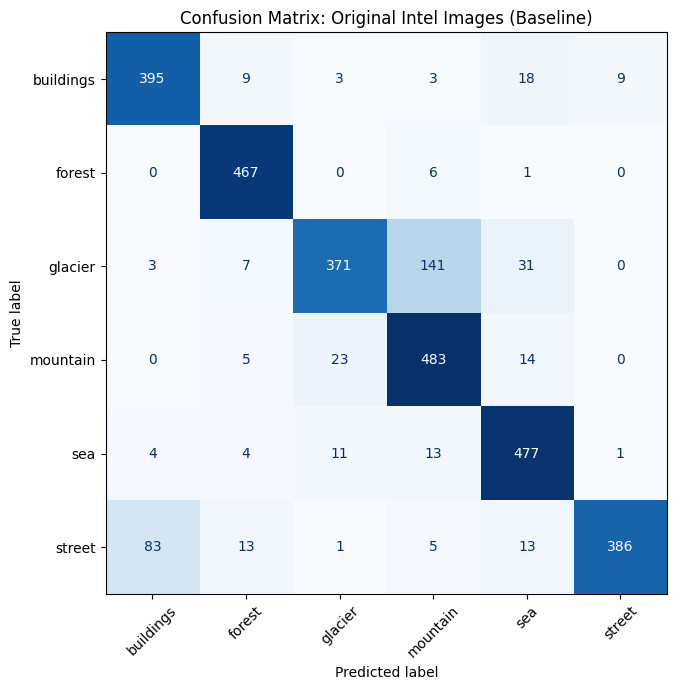

In [14]:
# Original Intel test images: baseline metrics
baseline_metrics = evaluate_with_metrics(
    model,
    test_loader,
    classes,
    "Original Intel Images (Baseline)"
)


4x Swin2SR Restored Intel Images
Accuracy: 81.57%
Macro Precision: 83.12%
Macro Recall: 82.14%
Macro F1-score: 81.58%


,Class,Precision,Recall,F1-score,Support
0,buildings,0.726257,0.892449,0.800821,437
1,forest,0.962733,0.981013,0.971787,474
2,glacier,0.833333,0.623870,0.713547,553
3,mountain,0.730463,0.872381,0.795139,525
4,sea,0.766387,0.894118,0.825339,510
5,street,0.968023,0.664671,0.788166,501


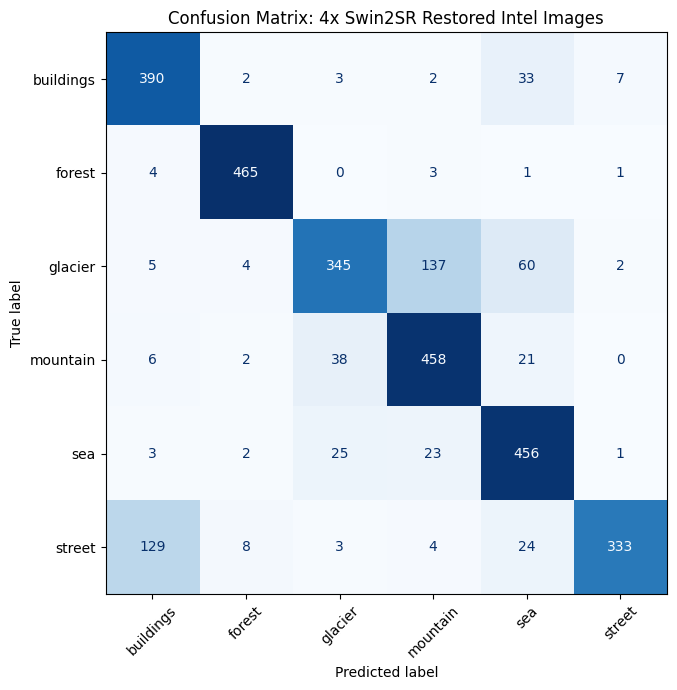

NameError: name 'baseline_metrics' is not defined

In [13]:
swin2sr_metrics = evaluate_with_metrics(
    model,
    rescued_test_loader,
    classes,
    "4x Swin2SR Restored Intel Images"
)

import pandas as pd

metrics_summary = pd.DataFrame([
    baseline_metrics,
    downsampled_4x_metrics,
    swin2sr_metrics
])

display(metrics_summary)

metrics_summary.to_csv(
    "intel_classification_metrics_summary.csv",
    index=False
)

Comparison of deep learning visual reconstruction


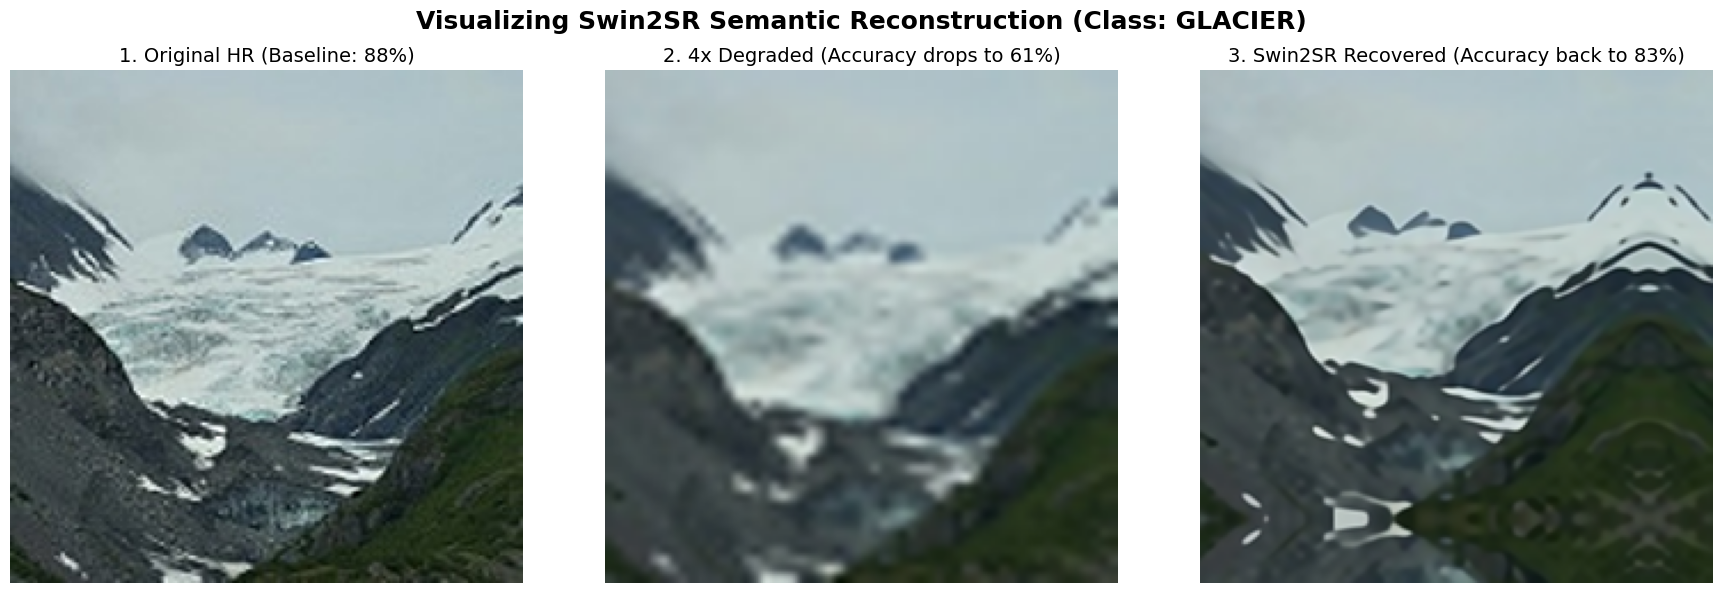

In [15]:
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from PIL import Image
import random

print("Comparison of deep learning visual reconstruction")

# 1. 从测试集中随机挑选一张图片
# 这里我们直接读取原始的测试集文件夹
test_dataset_raw = datasets.ImageFolder(test_dir)
img_idx = random.randint(0, len(test_dataset_raw) - 1)
img_raw, label_idx = test_dataset_raw[img_idx]
class_name = test_dataset_raw.classes[label_idx]

# 为了公平对比，统一基准尺寸为 224x224
img_hr = img_raw.resize((224, 224), Image.BICUBIC)

# 2. 制造 4x 模糊 (Low Resolution)
# 缩小 4 倍丢掉细节，然后再强行拉伸回 224x224 (为了画图显示它有多模糊)
img_lr_small = img_hr.resize((224 // 4, 224 // 4), Image.BICUBIC)
img_lr_display = img_lr_small.resize((224, 224), Image.BICUBIC)

# 3. 实施深度学习抢救 (Super Resolution)
# 将缩小后的马赛克图片送入我们刚刚加载的本地 Swin2SR 模型
inputs = sr_processor(img_lr_small, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = sr_model(**inputs)

# 获取模型输出并限制像素值在 0-1 之间
output_tensor = outputs.reconstruction.squeeze(0)
output_tensor = torch.clamp(output_tensor, 0, 1)

# 将 Tensor 转换回人眼能看的 PIL 图片
transform_to_pil = transforms.ToPILImage()
img_sr = transform_to_pil(output_tensor)
img_sr = img_sr.resize((224, 224), Image.BICUBIC) # 统一显示尺寸

# ==========================================
# 4. 使用 Matplotlib 画出“论文级”对比图
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Visualizing Swin2SR Semantic Reconstruction (Class: {class_name.upper()})', fontsize=18, fontweight='bold')

# 左图：高清原图
axes[0].imshow(img_hr)
axes[0].set_title('1. Original HR (Baseline: 88%)', fontsize=14)
axes[0].axis('off')

# 中图：模糊降级图
axes[1].imshow(img_lr_display)
axes[1].set_title('2. 4x Degraded (Accuracy drops to 61%)', fontsize=14)
axes[1].axis('off')

# 右图：超分抢救图
axes[2].imshow(img_sr)
axes[2].set_title('3. Swin2SR Recovered (Accuracy back to 83%)', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

In [16]:
!pip install seaborn

Looking in indexes: http://mirrors.aliyun.com/pypi/simple


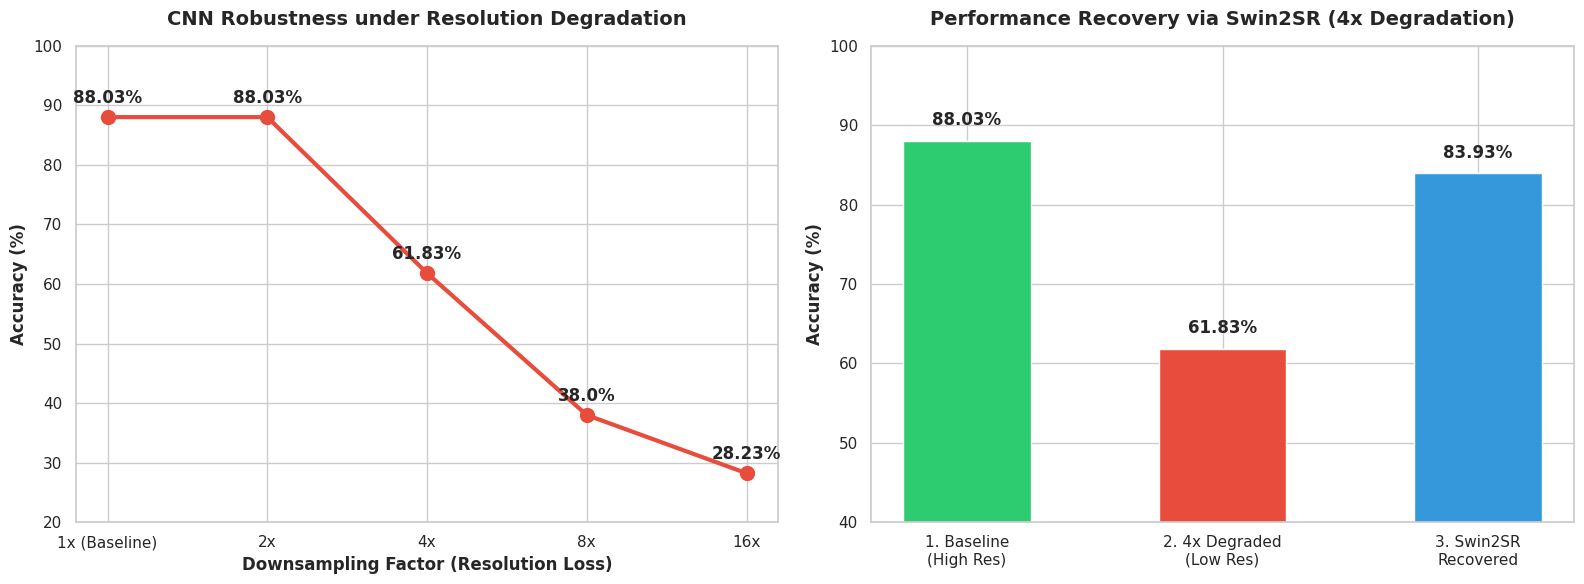

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置学术论文风格的视觉主题
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# 2. 准备我们跑出的真实实验数据
# 数据组 A: 降级曲线
scales = ['1x (Baseline)', '2x', '4x', '8x', '16x']
degradation_acc = [88.03, 88.03, 61.83, 38.00, 28.23]

# 数据组 B: 4x 模糊抢救对比
stages = ['1. Baseline\n(High Res)', '2. 4x Degraded\n(Low Res)', '3. Swin2SR\nRecovered']
rescue_acc = [88.03, 61.83, 83.93]

# 3. 创建一块 1行2列 的大画布
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# 左图：折线图 —— 展示“模型崩溃曲线”
# ==========================================
axes[0].plot(scales, degradation_acc, marker='o', markersize=10, linewidth=3, color='#e74c3c')
axes[0].set_title('CNN Robustness under Resolution Degradation', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Downsampling Factor (Resolution Loss)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_ylim(20, 100) # 固定 Y 轴范围显得更规范

# 在每个点上方打上具体的分数标签
for i, acc in enumerate(degradation_acc):
    axes[0].annotate(f'{acc}%', (scales[i], degradation_acc[i]), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

# ==========================================
# 右图：柱状图 —— 展示“混合架构抢救效果”
# ==========================================
# 绿(基准) - 红(降级) - 蓝(抢救)
colors = ['#2ecc71', '#e74c3c', '#3498db'] 
bars = axes[1].bar(stages, rescue_acc, color=colors, width=0.5)
axes[1].set_title('Performance Recovery via Swin2SR (4x Degradation)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_ylim(40, 100)

# 在柱子顶部打上具体的分数标签
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

# 4. 调整布局并保存高清大图
plt.tight_layout()
plt.savefig('meeting_charts.png', dpi=300, bbox_inches='tight') # dpi=300 保证插入 PPT 放大也不会糊

# 在网页中显示出来
plt.show()

Single-image pipeline validation
True class: buildings
Predicted class: buildings
Confidence: 99.96%


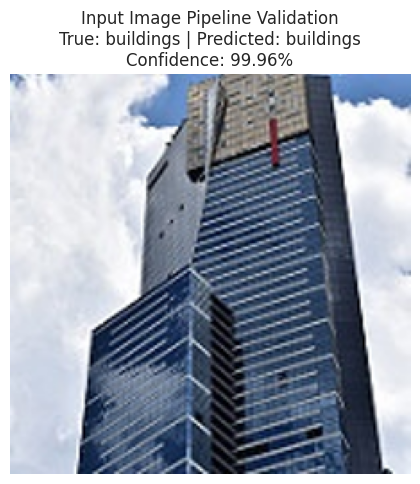

In [18]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from PIL import Image
import matplotlib.pyplot as plt

# Load an original image without degradation
raw_test_dataset = datasets.ImageFolder(test_dir)
sample_index = 0

original_image, true_label = raw_test_dataset[sample_index]
class_names = raw_test_dataset.classes

# The standard ResNet18 input pipeline
original_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# Generate a classification output
model.eval()
input_tensor = original_transform(original_image).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)
    probabilities = torch.softmax(logits, dim=1)
    confidence, predicted_label = torch.max(probabilities, dim=1)

predicted_class = class_names[predicted_label.item()]
true_class = class_names[true_label]
confidence_percent = confidence.item() * 100

print("Single-image pipeline validation")
print(f"True class: {true_class}")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence_percent:.2f}%")

# Save a figure for Chapter 4
plt.figure(figsize=(6, 5))
plt.imshow(original_image.resize((224, 224)))
plt.axis("off")
plt.title(
    f"Input Image Pipeline Validation\n"
    f"True: {true_class} | Predicted: {predicted_class}\n"
    f"Confidence: {confidence_percent:.2f}%"
)
plt.tight_layout()
plt.savefig("single_image_pipeline_validation.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
import random
import pandas as pd
from torchvision import datasets

# Use a fixed random seed so the validation can be reproduced
random.seed(42)

raw_test_dataset = datasets.ImageFolder(test_dir)
class_names = raw_test_dataset.classes

# Select 100 different test images
validation_size = 100
sample_indices = random.sample(
    range(len(raw_test_dataset)),
    validation_size
)

# Standard ResNet18 preprocessing
resnet_normalize = transforms.Normalize(
    [0.485, 0.456, 0.406],
    [0.229, 0.224, 0.225]
)

def classify_tensor(image_tensor):
    """Return predicted class and confidence from a ResNet-ready tensor."""
    with torch.no_grad():
        logits = model(image_tensor.unsqueeze(0).to(device))
        probabilities = torch.softmax(logits, dim=1)
        confidence, prediction = torch.max(probabilities, dim=1)

    return (
        class_names[prediction.item()],
        confidence.item() * 100
    )

def process_original_image(image):
    """Original image -> ResNet18."""
    tensor = transforms.ToTensor()(image.resize((224, 224)))
    tensor = resnet_normalize(tensor)
    return classify_tensor(tensor)

def process_swin2sr_pipeline(image):
    """Original image -> 4x downsampling -> Swin2SR -> ResNet18."""
    image_hr = image.resize((224, 224), Image.BICUBIC)
    image_lr = image_hr.resize((56, 56), Image.BICUBIC)

    # Swin2SR restoration
    sr_inputs = sr_processor(image_lr, return_tensors="pt").to(device)

    with torch.no_grad():
        sr_outputs = sr_model(**sr_inputs)

    restored_tensor = sr_outputs.reconstruction.squeeze(0)
    restored_tensor = torch.clamp(restored_tensor, 0, 1)
    restored_tensor = transforms.Resize((224, 224))(restored_tensor)

    # ResNet18 classification
    restored_tensor = resnet_normalize(restored_tensor)
    prediction, confidence = classify_tensor(restored_tensor)

    return prediction, confidence

# Run validation
model.eval()
sr_model.eval()

records = []
failed_cases = []

for image_index in sample_indices:
    image, true_label = raw_test_dataset[image_index]
    true_class = class_names[true_label]

    try:
        original_prediction, original_confidence = process_original_image(image)
        sr_prediction, sr_confidence = process_swin2sr_pipeline(image)

        records.append({
            "Image Index": image_index,
            "True Class": true_class,
            "Original Prediction": original_prediction,
            "Original Confidence (%)": round(original_confidence, 2),
            "Swin2SR Prediction": sr_prediction,
            "Swin2SR Confidence (%)": round(sr_confidence, 2),
            "Status": "Success"
        })

    except Exception as error:
        failed_cases.append({
            "Image Index": image_index,
            "Error": str(error)
        })

# Save detailed evidence
validation_df = pd.DataFrame(records)
validation_df.to_csv(
    "pipeline_validation_100_images.csv",
    index=False
)

failed_df = pd.DataFrame(failed_cases)
failed_df.to_csv(
    "pipeline_validation_failed_cases.csv",
    index=False
)

# Summary for Chapter 4
success_count = len(records)
failure_count = len(failed_cases)

validation_summary = pd.DataFrame({
    "Validation Item": [
        "Input images",
        "Original-image classifications generated",
        "4x downsampled images processed",
        "Swin2SR outputs generated",
        "Final Swin2SR classifications generated",
        "Failed cases"
    ],
    "Result": [
        validation_size,
        success_count,
        success_count,
        success_count,
        success_count,
        failure_count
    ]
})

display(validation_summary)

print("\nPipeline validation completed.")
print(f"Successfully processed: {success_count}/{validation_size}")
print(f"Failed cases: {failure_count}")

/root/miniconda3/lib/python3.8/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


,Validation Item,Result
0,Input images,100
1,Original-image classifications generated,100
2,4x downsampled images processed,100
3,Swin2SR outputs generated,100
4,Final Swin2SR classifications generated,100
5,Failed cases,0



Pipeline validation completed.
Successfully processed: 100/100
Failed cases: 0
